In [ ]:
import mne
print(mne.__version__)

1.12.0


In [3]:
# Download the MNE sample dataset (only runs once, ~1.5 GB)
data_path = mne.datasets.sample.data_path()
print(f"Data downloaded to: {data_path}")

Matplotlib is building the font cache; this may take a moment.


Using default location ~/mne_data for sample...
Creating /Users/aleksandraszymanska/mne_data
Fetching 1 file for the sample dataset ...


/Users/aleksandraszymanska/Desktop/eeg-pipeline/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|█████████████████████████████████████| 1.65G/1.65G [00:00<00:00, 2.17TB/s]
Untarring contents of '/Users/aleksandraszymanska/mne_data/MNE-sample-data-processed.tar.gz' to '/Users/aleksandraszymanska/mne_data'


Attempting to create new mne-python configuration file:
/Users/aleksandraszymanska/.mne/mne-python.json
Could not read the /Users/aleksandraszymanska/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m12s (1576.2 MB)
Data downloaded to: /Users/aleksandraszymanska/mne_data/MNE-sample-data


In [4]:
# Define the path to the raw file
raw_fif_path = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"

# Load the raw data
raw = mne.io.read_raw_fif(raw_fif_path, preload=True)

# See basic info
print(raw.info)

Opening raw data file /Users/aleksandraszymanska/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 H

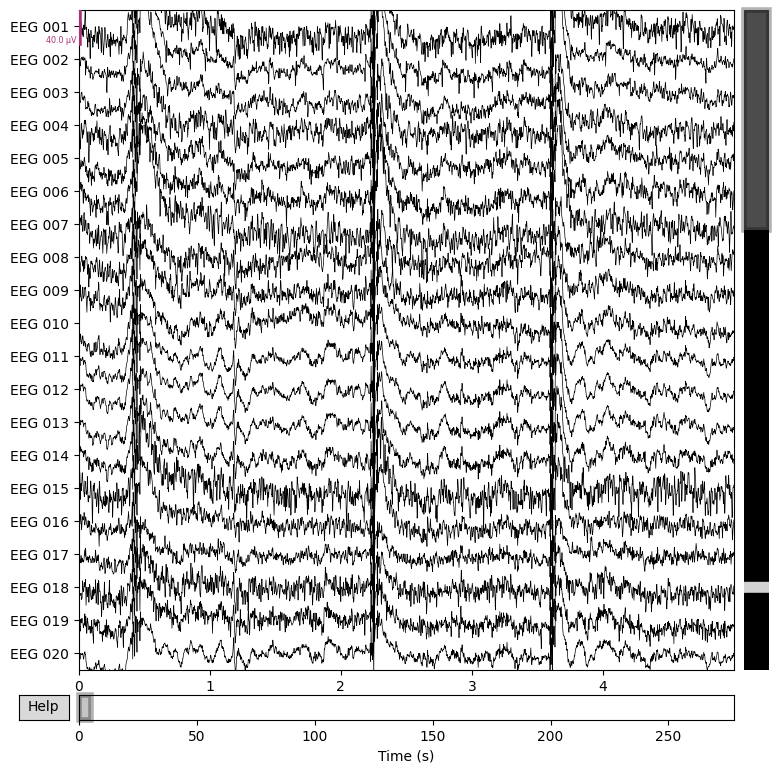

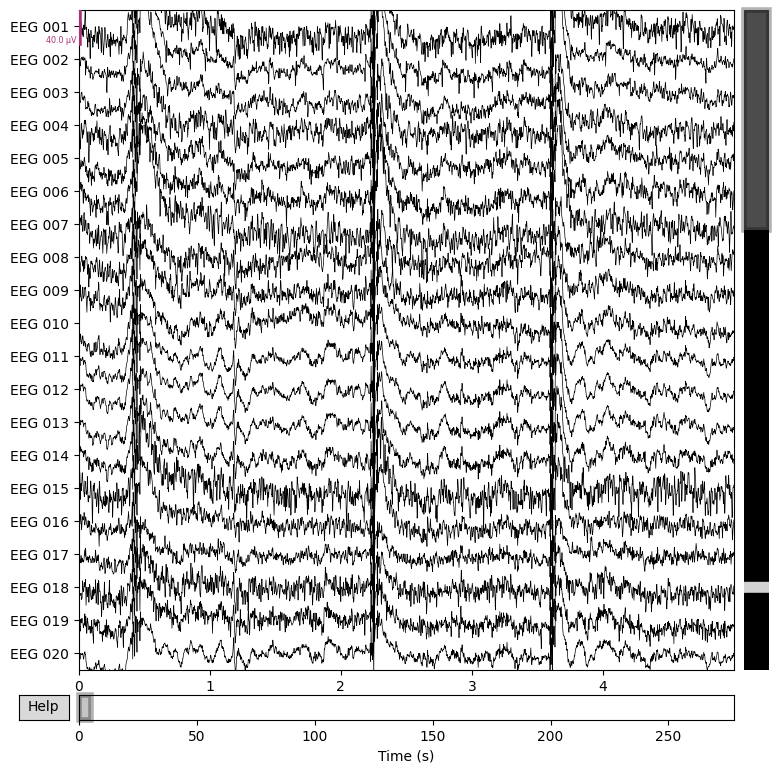

In [10]:
# Plot just the EEG channels (60 of them), 5 seconds at a time
raw.copy().pick('eeg').plot(duration=5, n_channels=20)

In [11]:
# Get the actual data as a numpy array
eeg_data = raw.copy().pick('eeg').get_data()

print(f"Shape: {eeg_data.shape}")
print(f"This means: {eeg_data.shape[0]} channels × {eeg_data.shape[1]} time points")
print(f"Duration: {eeg_data.shape[1] / raw.info['sfreq']:.1f} seconds")

Shape: (60, 166800)
This means: 60 channels × 166800 time points
Duration: 277.7 seconds


In [12]:
# Look at the actual voltage values
print(f"Min value: {eeg_data.min() * 1e6:.1f} µV")
print(f"Max value: {eeg_data.max() * 1e6:.1f} µV")
print(f"Mean: {eeg_data.mean() * 1e6:.2f} µV")

Min value: -301.0 µV
Max value: 426.5 µV
Mean: 60.09 µV
